Authenticated using refresh token.
✅ Connected!

Step 1: Loading saved NBR data...
✅ NBR data loaded!

Step 2: Loading saved fire detection data...
✅ Fire detection loaded! Active fire: 62.05 km²

Step 3: Running burn severity classification...
✅ Classification done! Total burned: 801.18 km²

Step 4: Generating unified map...


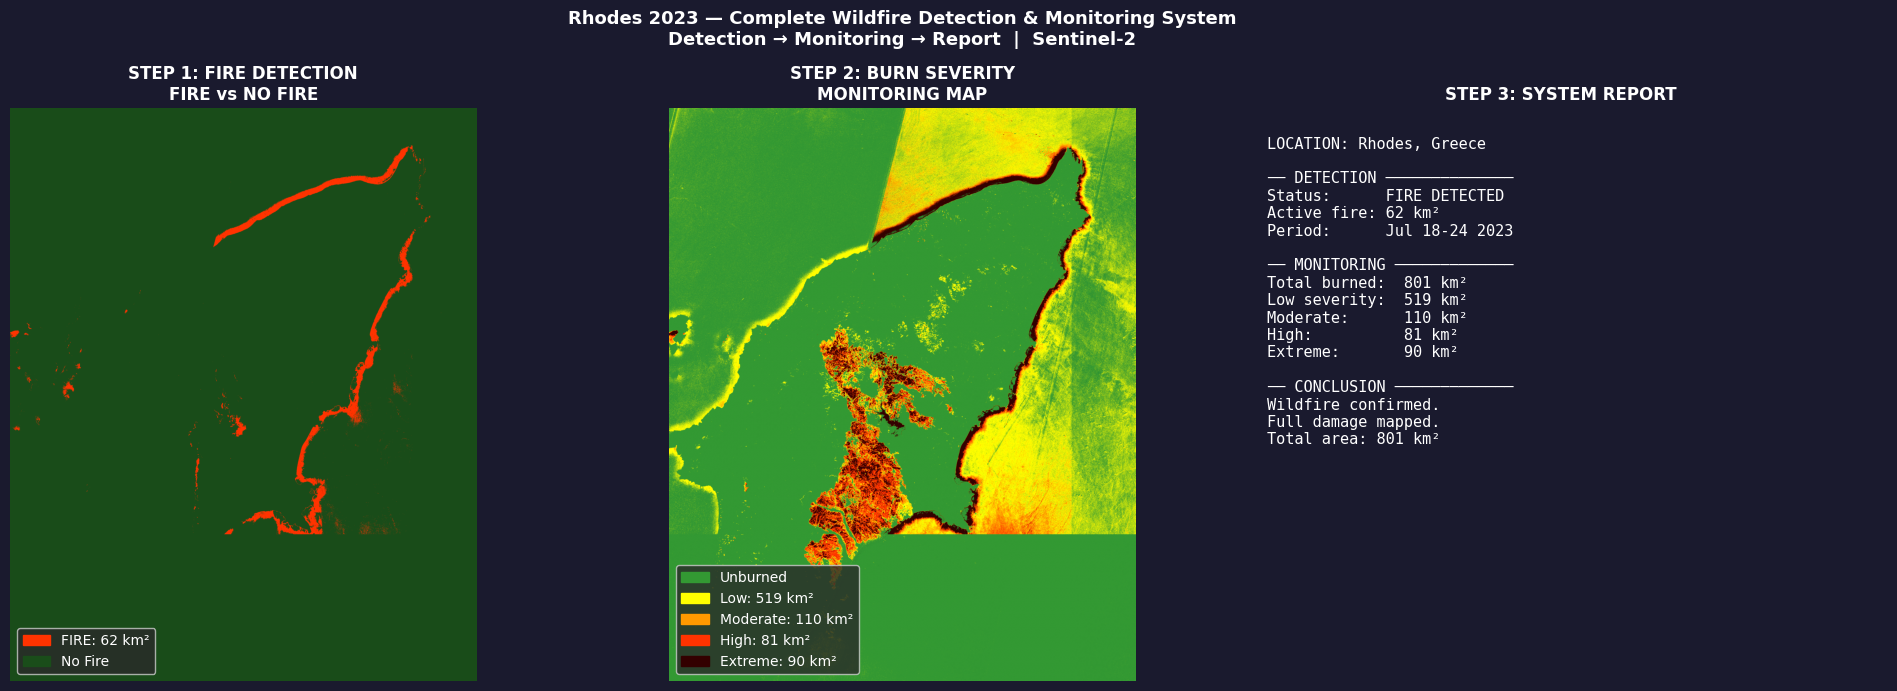


  FINAL REPORT
  Fire detected:   YES
  Active fire:     62.05 km²
  Total burned:    801.18 km²
  Low severity:    519.26 km²
  Moderate:        110.46 km²
  High:            81.24 km²
  Extreme:         90.21 km²
✅ Complete system finished!


In [12]:
import openeo
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── CONNECT ───────────────────────────────────────────────
connection = openeo.connect("openeo.dataspace.copernicus.eu")
connection.authenticate_oidc()
print("✅ Connected!")

# ── STUDY AREA ────────────────────────────────────────────
spatial_extent = {"west":27.7,"east":28.3,"south":35.9,"north":36.5}
pre_fire     = ["2023-07-01", "2023-07-17"]
during_fire  = ["2023-07-18", "2023-07-24"]
post_fire    = ["2023-07-25", "2023-08-15"]

# ── RUN COMPLETE ANALYSIS ─────────────────────────────────
print("\nStep 1: Loading saved NBR data...")
with rasterio.open("pre_fire_nbr.tif") as src:
    pre_nbr = src.read(1).astype(float)
with rasterio.open("post_fire_nbr.tif") as src:
    post_nbr = src.read(1).astype(float)
pre_nbr[pre_nbr==0]   = np.nan
post_nbr[post_nbr==0] = np.nan
dnbr = pre_nbr - post_nbr
print("✅ NBR data loaded!")

print("\nStep 2: Loading saved fire detection data...")
with rasterio.open("during_fire_bands.tif") as src:
    B8A = src.read(1).astype(float)
    B11 = src.read(2).astype(float)
    B12 = src.read(3).astype(float)
B8A[B8A==0]=np.nan; B11[B11==0]=np.nan; B12[B12==0]=np.nan
with np.errstate(divide='ignore', invalid='ignore'):
    NBFI = np.where((B12+B8A)!=0, (B12-B8A)/(B12+B8A), np.nan)
fire_mask = np.zeros_like(NBFI, dtype=np.uint8)
fire_mask[NBFI > 0.5]      = 1
fire_mask[np.isnan(NBFI)]  = 255
fire_area_km2 = np.sum(fire_mask==1) * 0.0001
print(f"✅ Fire detection loaded! Active fire: {fire_area_km2:.2f} km²")

print("\nStep 3: Running burn severity classification...")
pixel_km2  = 0.0001
classified = np.zeros_like(dnbr, dtype=np.uint8)
classified[dnbr < 0.1]                     = 0
classified[(dnbr >= 0.1) & (dnbr < 0.27)]  = 1
classified[(dnbr >= 0.27) & (dnbr < 0.44)] = 2
classified[(dnbr >= 0.44) & (dnbr < 0.66)] = 3
classified[dnbr >= 0.66]                    = 4
classified[np.isnan(dnbr)]                  = 255
low      = np.sum(classified==1)
moderate = np.sum(classified==2)
high     = np.sum(classified==3)
extreme  = np.sum(classified==4)
total_burned = (low+moderate+high+extreme) * pixel_km2
print(f"✅ Classification done! Total burned: {total_burned:.2f} km²")

print("\nStep 4: Generating unified map...")

# Fire detection map
fire_rgb = np.zeros((*fire_mask.shape, 3), dtype=float)
fire_rgb[fire_mask==0]   = (0.1, 0.3, 0.1)
fire_rgb[fire_mask==1]   = (1.0, 0.2, 0.0)
fire_rgb[fire_mask==255] = (0.0, 0.0, 0.0)

# Burn severity map
severity_colors = {
    0:(0.2,0.6,0.2), 1:(1.0,1.0,0.0),
    2:(1.0,0.6,0.0), 3:(1.0,0.2,0.0),
    4:(0.2,0.0,0.0), 255:(0.0,0.0,0.0)
}
rgb_sev = np.zeros((*classified.shape, 3), dtype=float)
for val, col in severity_colors.items():
    rgb_sev[classified==val] = col

# Plot unified map
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor('#1a1a2e')

# Panel 1 - Detection
axes[0].imshow(fire_rgb)
axes[0].set_title("STEP 1: FIRE DETECTION\nFIRE vs NO FIRE",
                  fontsize=12, fontweight="bold", color="white")
axes[0].axis("off")
legend0 = [
    mpatches.Patch(color=(1.0,0.2,0.0), label=f"FIRE: {fire_area_km2:.0f} km²"),
    mpatches.Patch(color=(0.1,0.3,0.1), label="No Fire"),
]
axes[0].legend(handles=legend0, loc="lower left", fontsize=10,
               facecolor='#2a2a2a', labelcolor='white')

# Panel 2 - Monitoring
axes[1].imshow(rgb_sev)
axes[1].set_title("STEP 2: BURN SEVERITY\nMONITORING MAP",
                  fontsize=12, fontweight="bold", color="white")
axes[1].axis("off")
legend1 = [
    mpatches.Patch(color=(0.2,0.6,0.2), label="Unburned"),
    mpatches.Patch(color=(1.0,1.0,0.0), label=f"Low: {low*pixel_km2:.0f} km²"),
    mpatches.Patch(color=(1.0,0.6,0.0), label=f"Moderate: {moderate*pixel_km2:.0f} km²"),
    mpatches.Patch(color=(1.0,0.2,0.0), label=f"High: {high*pixel_km2:.0f} km²"),
    mpatches.Patch(color=(0.2,0.0,0.0), label=f"Extreme: {extreme*pixel_km2:.0f} km²"),
]
axes[1].legend(handles=legend1, loc="lower left", fontsize=10,
               facecolor='#2a2a2a', labelcolor='white')

# Panel 3 - Report
axes[2].set_facecolor('#2a2a2a')
axes[2].axis("off")
axes[2].set_title("STEP 3: SYSTEM REPORT",
                  fontsize=12, fontweight="bold", color="white")
report_text = (
    f"LOCATION: Rhodes, Greece\n\n"
    f"── DETECTION ──────────────\n"
    f"Status:      FIRE DETECTED\n"
    f"Active fire: {fire_area_km2:.0f} km²\n"
    f"Period:      Jul 18-24 2023\n\n"
    f"── MONITORING ─────────────\n"
    f"Total burned:  {total_burned:.0f} km²\n"
    f"Low severity:  {low*pixel_km2:.0f} km²\n"
    f"Moderate:      {moderate*pixel_km2:.0f} km²\n"
    f"High:          {high*pixel_km2:.0f} km²\n"
    f"Extreme:       {extreme*pixel_km2:.0f} km²\n\n"
    f"── CONCLUSION ─────────────\n"
    f"Wildfire confirmed.\n"
    f"Full damage mapped.\n"
    f"Total area: {total_burned:.0f} km²"
)
axes[2].text(0.05, 0.95, report_text,
            transform=axes[2].transAxes,
            fontsize=11, color='white',
            fontfamily='monospace',
            verticalalignment='top')

plt.suptitle("Rhodes 2023 — Complete Wildfire Detection & Monitoring System\n"
             "Detection → Monitoring → Report  |  Sentinel-2",
             fontsize=13, fontweight="bold", color="white")
plt.tight_layout()
plt.savefig("complete_system.png", dpi=150,
            bbox_inches="tight", facecolor='#1a1a2e')
plt.show()

print("\n" + "="*50)
print("  FINAL REPORT")
print("="*50)
print(f"  Fire detected:   YES")
print(f"  Active fire:     {fire_area_km2:.2f} km²")
print(f"  Total burned:    {total_burned:.2f} km²")
print(f"  Low severity:    {low*pixel_km2:.2f} km²")
print(f"  Moderate:        {moderate*pixel_km2:.2f} km²")
print(f"  High:            {high*pixel_km2:.2f} km²")
print(f"  Extreme:         {extreme*pixel_km2:.2f} km²")
print("="*50)
print("✅ Complete system finished!")